<style>
    pre {
        white-space: pre-wrap;
        word-wrap: break-word;
    }
</style>

<div style="display:flex; justify-content:space-around; align-items:center; background-color:#cccccc; padding:5px; border:2px solid #333333;">
    <a href="https://www.um.es/web/estudios/grados/ciencia-ingenieria-datos/" target="_blank">
    <img src="https://www.um.es/documents/1073494/42130150/LogosimboloUMU-positivo.png" alt="UMU" style="height:200px; width:auto;">
    <a href="https://estudios.upct.es/grado/5251/inicio" target="_blank">
    <img src="https://www.upct.es/contenido/universidad/galeria/identidad-2021/logos/logos-upct/marca-upct/marca-principal/horizontal/azul.png" alt="UPCT" style="height:145px; width:auto;">
</div>

# Asignatura: **Deep Learning**

## Titulación: **Grado en Ciencia e Ingeniería de Datos**

## Práctica 2: Redes Convolucionales
### **Sesión 2/3: La arquitectura U-Net**

**Autores**: Antonio Martínez Sánchez, Juan Morales Sánchez, José Luís Sancho Gómez y Juan Antonio Botía Blaya

<div style="page-break-before: always;"></div>

### Contenidos
- [Requisitos](#requisitos)
- [La arquitectura U-Net](#unet)
- [El dataset](#dataset)
- [Restauración de imágenes](#restauración)
- [Entrenamiento](#entrenamiento)
- [Ejercicios](#ejercicios)

### Requisitos
<a class='anchor' id='requisitos'></a>

Se trabajará con notebooks de [Jupyter](https://jupyter.org/install) con código Python empleando como intérprete la última versión de [Miniconda](https://docs.anaconda.com/miniconda/). Se requiere la preinstalación (se recomienda utilizar [pip](https://pypi.org/project/pip/)) de los siguientes paquetes de Python:

- [Numpy](https://pypi.org/project/numpy/) (computación numérica)
- [Scipy](https://pypi.org/project/scipy/) (computación científica)
- [Tensorflow](https://www.tensorflow.org/install/pip?hl=es-419#linux) que incluye a Keras (deep Learning)
- [Scikit-learn](https://pypi.org/project/scikit-learn/) (machine Learning)
- [Mrcfile](https://pypi.org/project/mrcfile/) (operationes E/S en ficheros MRC)
- [Matplotlib](https://pypi.org/project/matplotlib/) (visualización de datos)

Además, para la visualización 3D se recomienda la utilización de [Paraview](https://www.paraview.org/).

### La arquitectura U-Net
<a class='anchor' id='unet'></a>

Como hemos visto en el tema 2, cuando hablamos de segmentación, en algunas tareas de análisis de imagen es necesario trabajar a nivel de píxel en lugar de tomar una decisión, p.e.  clasificación, analizando el conjunto de la imagen. Para poder trabajar a este nivel, se requiere de una arquitectura encoder-decoder, de tal forma que primero un encoder analiza el contenido de la imagen y depués un decoder reconstruye la imagen resultante, la cual tendrá el mismo tamaño y estructura que la de entrada. 

Esta arquitectura se corresponde con la de un autoencoder, que se estudiará con detalle en la Práctica 4 en el Tema 6 de Teoría. Los autoencoders trabajan de una forma muy característica, comprimiendo la imagen de entrada de forma progresiva hasta llegar al espacio latente deseado y, desde ahí, pasar a reconstruir la imagen original. Normalmente, como la información suele comprimirse demasiado, se hace después difícil para el decoder reconstruir la imagen con suficiente precisión. 

Para conseguir una reconstrucción con precisión a nivel de píxel en U-Net se introdujo una innovación, consistente en conectar capas homólogas en encoder y decoder de forma directa, las *skip connections*, y así el decoder puede realizar la tarea de reconstrucción de forma más efectiva, al suministrásele más información para la tarea. La arquitectura inicialmente propuesta se encuentra descrita aquí 

![Arquitectura U-Net para segmentación de imágenes médicas](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/u-net-architecture.png)

Más información sobre esta red, incluyendo un video explicativo, disponible en la web de los autores [https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/](https://lmb.informatik.uni-freiburg.de/people/ronneber/u-net/).

En esta sesión de prácticas vamos a construir una red U-Net para restaurar imágenes altamente ruidosas de cryo-EM.

### El dataset
<a class='anchor' id='dataset'></a>

Se procesarán imágenes almacenadas en ficheros en formato [MRC](https://www.ccpem.ac.uk/mrc-format). Este formato soporta imágenes en 2D, 3D y secuencias de imágenes. Se llama así porque fue desarrollado por el MRC (Medical Research Council) del Reino Unido. 
Para leer este formato de almacenamiento se necesita el paquete *mrcfile*. 
Procedemos a instalarlo si no lo tenemos con 
```bash
pip install mrcfile
```

A modo de ejemplo sobre su uso se proporciona la siguiente función tomada del repositorio [PolNet](https://github.com/anmartinezs/polnet/blob/506309bb815d395131c97100272ce47b5c07d2d3/polnet/lio.py#L17C1-L32C20):

```python
import mrcfile

def load_mrc(fname, mmap=False, no_saxes=True):
    """
    Load an input MRC tomogram as ndarray

    :param fname: the input MRC
    :param mmap: if True (default False) the data are read as a memory map
    :param no_saxes: if True (default) then X and Y axes are swaped to cancel the swaping made by mrcfile package
    :return: a ndarray (or memmap is mmap=True)
    """
    if mmap:
        mrc = mrcfile.mmap(fname, permissive=True, mode='r+')
    else:
        mrc = mrcfile.open(fname, permissive=True, mode='r+')
    if no_saxes:
        return np.swapaxes(mrc.data, 0, 2)
    return mrc.data
```

El directorio con las imágenes es *imgs/SNR_high*, con un contenido similar al de la sesión anterior pero ahora las imágenes son mucho más ruidosas. El subdirectorio *noisy* contine las imágenes ruidosas y *clean* contiene la imágenes sin ruido, necesarias para poder realizar un aprendizaje supervisado.

El formato MRC se utiliza para almacenar tomografías y pilas de imágenes, esto es imágenes 3D generadas a partir de una secuencia de imágenes en 2D. En este caso, los archivos contienen una sola imagen 2D con diferentes tamaños. Antes de construir los tensores de entrada para la red, las imágenes se tienen que recortar para que todas tengan un tamaño 56x56 píxeles, es importante que se mantenga la parte central de la imagen durante el recorte. 

### Restauración de imágenes
<a class='anchor' id='restauracion'></a>

En esta sesión se resolverá el problema de la restauración de imágenes empleando una red U-Net. En algunos dominios de aplicación, como la microscopía electrónica, las imágenes sufren distorsiones y ruido introducidos por los sistemas de adquisición. La restauración, o filtrado de ruido, consiste en eliminar <u>en la medida de lo posible</u> estas distorsiones y ruido para recuperar una imagen que permita una mejor visualización del contenido de la escena que hay en la imagen:

![Restauracion](restauracion.png)

En el artículo [DeepFinder](https://doi.org/10.1038/s41592-021-01275-4) se describe una red neuronal con arquitectura U-Net empleada para procesar tomograma, imágenes 3D. La siguiente imagen resume su arquitectura:

![DeepFinder](deepfinder_unet.png)

En esta práctica se utilizará esta arquitectura como referencia para construir una red U-Net para la restauración de imágenes 2D. Por tanto, habrá que modificar los parámetros de los bloques convolucionales para procesar imágenes 2D en lugar de 3D. Por otro lado, es importante resaltar que la imagen restaurada (salida) debe tener el mismo tamaño que la imagen distorsionada (entrada), por tanto los bloques convolucionales han de configurarse adecuadamente utilizando el atributo *padding* de la clase Conv2D de Keras. Además, es importante recordar que en esta red no existe un solo flujo secuencial, las dos conexiones directas entre los bloques convolucionales análogos del encoder y el decoder se pueden establecer mediante la función *concatenate* de Keras.

La red U-Net recibe imágenes a la entrada, procesándolas y devolviendo imágenes del mismo tamaño a la salida. Por lo tanto, no necesita de capas densas a la salida. No obstante, es clave adpatar la activación de la última capa, la que generará la imagenes de salida, al tipo de problema que estamos tratando. En este caso, queremos que la salida se un mapa escalar en 2D, una función $\mathbb{R}^2 \rightarrow \mathbb{R}$, luego la función de activación a la salida deber ser lineal. Para el resto de capas DeepFinder utiliza ReLU. Un problema de restauración de imágenes se puede entender como un problema de regresión a nivel de píxel, por tanto, MSE es una posible función de pérdidas. 


### Entrenamiento
<a class='anchor' id='entrenamiento'></a>

En cualquier algoritmo de machine learning el reto durante el entramiento es que el algoritmo aprenda pero sin llegar a sobreajustarse a los datos de entrenamiento. Es por esto que es frecuente añadir suficientes épocas durante el entrenamiento hasta que se produzca el sobreajuste, el problema es que el modelo final resultado del entrenamiento estará sobre ajustado. 

Existen varias estrategias para obtener modelos aproximadamente óptimos, cuando la función de pérdidas llega al mínimo durante el entrenamiento. Una es fijar las épocas para asegurar sobreajuste y durante el entrenamiento ir guardando modelos intermedios, esta opción requiere disponer del espacio para ir almacenando los modelos con suficiente precisión. Otra estrategia fácilmente implementable usando tensorflow es el mecanismo de parada anticipada o *early stopping*, en este caso se utilizan funciones que monitorizan el proceso de entrenamiento para que se detenga si se dan unas ciertas condiciones.

### Ejercicios
<a class='anchor' id='ejercicios'></a>

**E1:** Carga las imágenes de entrada del directorio y preprocésalas según se especifica en la sección [El dataset](#dataset). Almacénalas en tensores con las dimensiones adecuadas para servir de entrada y/o salida una red U-Net.

**E2:** Aleatoriza la posicion de las imágenes y consecuentemente los identificadores.

**E3:** Particiona los tensores de entrada en dos, asigna el 80% de las imágenes para el entrenamiento y el 20% para la validación.

**E4:** Adapta la arquitectura mostrada en la sección [Restauración de imágenes](#restauracion) red para resolver la tarea de restauración de las imágenes cargadas en el ejercicio anterior. Utiliza el esquema presentado en esta sección para construir la arquitectura, pero <u>adaptalo a 2D utilizando las recomendaciones</u> de la propia sección.

**E5:** Entrénala teniendo en cuenta la función de perdidas que mejor se ajusta al problema de restauración propuesto. Fija unos parámetros que te permitan conseguir sobreajuste.

**E6:** Visualiza algunos ejemplos de imágenes restauradas (procesadas por la red) comparadas con las imágenes de partida (transformadas por el microscopio) y las imágenes sin distorsiones (originales). ¿Se consigue eliminar el ruido? ¿Se consigue restaurar perfectamente la estructura de la molécula original?

**E7:** Repite los ejercicios E5 e E6 pero añadiendo unos mecanismos de parada temprana para evitar la aparición de sobreajuste. ¿Cuánto dura ahora el entrenamiento? ¿Se ha conseguido un mejor resultado? ¿Por qué?

In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import mrcfile
import os
import glob
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D,
                                     UpSampling2D, concatenate)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1772449988.559288   34501 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1772449988.589847   34501 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1772449989.385595   34501 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
# ============================================================
# E1: Carga y preprocesado de imágenes
# ============================================================

def load_mrc(fname, mmap=False, no_saxes=True):
    """Load an input MRC file as ndarray."""
    if mmap:
        mrc = mrcfile.mmap(fname, permissive=True, mode='r+')
    else:
        mrc = mrcfile.open(fname, permissive=True, mode='r+')
    if no_saxes:
        return np.swapaxes(mrc.data, 0, 2)
    return mrc.data


def center_crop(img, target_size=56):
    """Recorta la imagen manteniendo la parte central."""
    h, w = img.shape[:2]
    start_h = (h - target_size) // 2
    start_w = (w - target_size) // 2
    return img[start_h:start_h + target_size, start_w:start_w + target_size]


# Rutas a los directorios
base_dir = "imgs/SNR_low"
noisy_dir = os.path.join(base_dir, "noisy")
clean_dir = os.path.join(base_dir, "clean")

# Cargar imágenes ruidosas y limpias
noisy_files = sorted(glob.glob(os.path.join(noisy_dir, "*.mrc")))
clean_files = sorted(glob.glob(os.path.join(clean_dir, "*.mrc")))

print(f"Número de imágenes ruidosas: {len(noisy_files)}")
print(f"Número de imágenes limpias: {len(clean_files)}")

TARGET_SIZE = 56
noisy_images = []
clean_images = []

for nf, cf in zip(noisy_files, clean_files):
    noisy_img = load_mrc(nf)
    clean_img = load_mrc(cf)

    # Si la imagen tiene 3 dimensiones pero la tercera es 1 (una sola slice),
    # eliminar esa dimensión
    if noisy_img.ndim == 3:
        noisy_img = noisy_img.squeeze()
    if clean_img.ndim == 3:
        clean_img = clean_img.squeeze()

    # Recortar al tamaño objetivo 56x56
    noisy_img = center_crop(noisy_img, TARGET_SIZE)
    clean_img = center_crop(clean_img, TARGET_SIZE)

    noisy_images.append(noisy_img)
    clean_images.append(clean_img)

# Convertir a arrays numpy
noisy_images = np.array(noisy_images, dtype=np.float32)
clean_images = np.array(clean_images, dtype=np.float32)

# Añadir dimensión de canal (N, 56, 56) -> (N, 56, 56, 1)
noisy_images = noisy_images[..., np.newaxis]
clean_images = clean_images[..., np.newaxis]

print(f"Tensor de imágenes ruidosas (entrada): {noisy_images.shape}")
print(f"Tensor de imágenes limpias (salida):   {clean_images.shape}")

Número de imágenes ruidosas: 500
Número de imágenes limpias: 500
Tensor de imágenes ruidosas (entrada): (500, 56, 56, 1)
Tensor de imágenes limpias (salida):   (500, 56, 56, 1)


In [3]:
# ============================================================
# E2: Aleatorizar posiciones
# ============================================================

n_samples = noisy_images.shape[0]
indices = np.arange(n_samples)
np.random.seed(42)
np.random.shuffle(indices)

noisy_images = noisy_images[indices]
clean_images = clean_images[indices]

print(f"Índices aleatorizados (primeros 10): {indices[:10]}")

# ============================================================
# E3: Partición entrenamiento (80%) / validación (20%)
# ============================================================

X_train, X_val, Y_train, Y_val = train_test_split(
    noisy_images, clean_images, test_size=0.2, random_state=42
)

print(f"Entrenamiento - entrada: {X_train.shape}, salida: {Y_train.shape}")
print(f"Validación    - entrada: {X_val.shape}, salida: {Y_val.shape}")

Índices aleatorizados (primeros 10): [361  73 374 155 104 394 377 124  68 450]
Entrenamiento - entrada: (400, 56, 56, 1), salida: (400, 56, 56, 1)
Validación    - entrada: (100, 56, 56, 1), salida: (100, 56, 56, 1)


In [4]:
# ============================================================
# E4: Arquitectura U-Net 2D (basada en DeepFinder)
# ============================================================
# La arquitectura de DeepFinder tiene:
# Encoder: 3 bloques conv (cada uno con 2 Conv + ReLU) + MaxPool
# Bottleneck: 1 bloque conv
# Decoder: 3 bloques (UpSampling + concatenate skip + 2 Conv + ReLU)
# Salida: Conv2D con 1 filtro y activación lineal
#
# Filtros según DeepFinder: 32 -> 64 -> 128 -> 256 (bottleneck)
# y luego 128 -> 64 -> 32 en el decoder

def build_unet(input_shape=(56, 56, 1)):
    inputs = Input(shape=input_shape)

    # --- Encoder ---
    # Bloque 1: 32 filtros
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)  # 56 -> 28

    # Bloque 2: 64 filtros
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)  # 28 -> 14

    # Bloque 3: 128 filtros
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)  # 14 -> 7

    # --- Bottleneck ---: 256 filtros
    bn = Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    bn = Conv2D(256, (3, 3), activation='relu', padding='same')(bn)

    # --- Decoder ---
    # Bloque 4: 128 filtros
    u4 = UpSampling2D((2, 2))(bn)  # 7 -> 14
    u4 = concatenate([u4, c3])     # Skip connection
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(u4)
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    # Bloque 5: 64 filtros
    u5 = UpSampling2D((2, 2))(c4)  # 14 -> 28
    u5 = concatenate([u5, c2])     # Skip connection
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(u5)
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    # Bloque 6: 32 filtros
    u6 = UpSampling2D((2, 2))(c5)  # 28 -> 56
    u6 = concatenate([u6, c1])     # Skip connection
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(c6)

    # Capa de salida: 1 filtro, activación lineal (regresión)
    outputs = Conv2D(1, (1, 1), activation='linear', padding='same')(c6)

    model = Model(inputs=inputs, outputs=outputs)
    return model


model = build_unet(input_shape=(TARGET_SIZE, TARGET_SIZE, 1))
model.summary()

W0000 00:00:1772449990.820154   34501 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1772449990.832387   34501 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1772449990.970305   34501 gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was false.
I0000 00:00:1772449990.971267   34501 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5783 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 56, 56, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 56, 56,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 28, 28,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 28, 28,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 14, 14,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 14, 14,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 7, 7, 128) │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 7, 7, 256) │    295,168 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 7, 7, 256) │    590,080 │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 14, 14,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 14, 14,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 14, 14,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 14, 14,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 28, 28,    │          0 │ conv2d_9[0][0]    │
│ (UpSampling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,946,305 (7.42 MB)

 Trainable params: 1,946,305 (7.42 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200


I0000 00:00:1772449993.278287   34665 service.cc:153] XLA service 0x70693c0427f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772449993.278302   34665 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5060 Laptop GPU, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.18.1)
I0000 00:00:1772449993.341599   34665 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1772449993.719718   34665 cuda_dnn.cc:461] Loaded cuDNN version 91801


18/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 84.4299 - mae: 4.4571

I0000 00:00:1772449999.793522   34665 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - loss: 63.8064 - mae: 3.4693 - val_loss: 53.5829 - val_mae: 3.1183
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 41.3072 - mae: 2.8585 - val_loss: 26.8162 - val_mae: 2.2491
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 22.7210 - mae: 1.9469 - val_loss: 23.2626 - val_mae: 2.1076
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 25.0224 - mae: 1.8294 - val_loss: 20.6660 - val_mae: 1.7488
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 16.3547 - mae: 1.4917 - val_loss: 15.8232 - val_mae: 1.4479
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 14.1379 - mae: 1.4084 - val_loss: 14.4305 - val_mae: 1.3086
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 13.2862 - mae: 1.2576 - val_loss: 13.9644 - val_mae: 1.2699
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 12.9373 - mae: 1.2519 - val_loss: 14.0659 - val_mae: 1.2833
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/ste

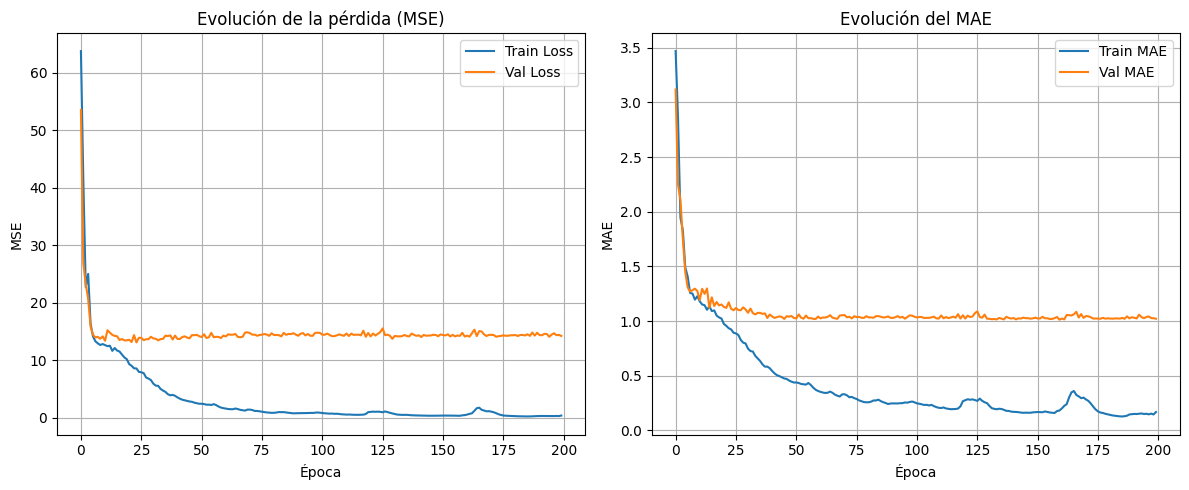

In [5]:
# ============================================================
# E5: Entrenamiento (con sobreajuste)
# ============================================================

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Entrenamiento largo para conseguir sobreajuste
history = model.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=200,
    batch_size=16,
    verbose=1
)

# Visualizar curvas de pérdida
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Evolución de la pérdida (MSE)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.title('Evolución del MAE')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('e5_training_curves.png', dpi=150)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step


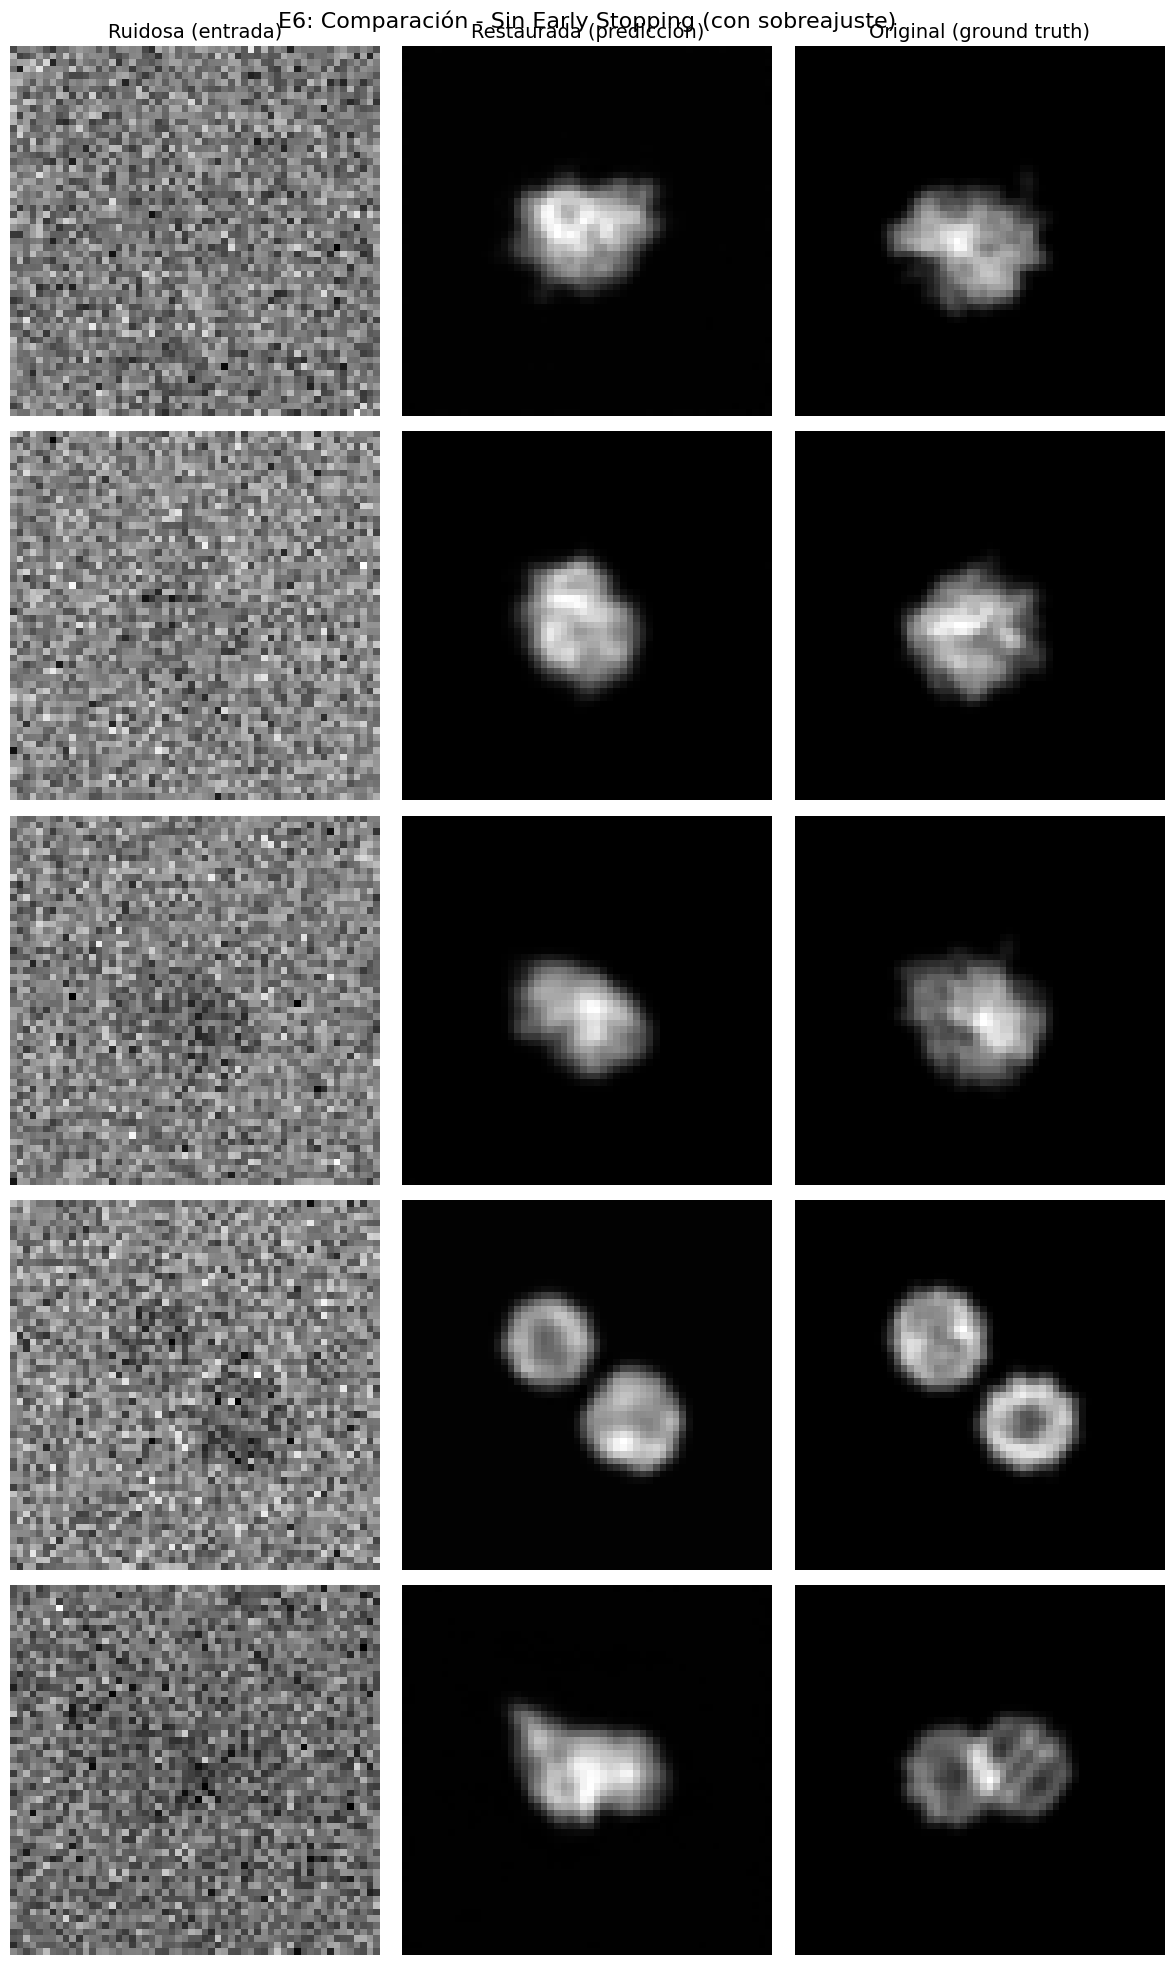

In [6]:
# ============================================================
# E6: Visualización de resultados
# ============================================================

# Predecir sobre las imágenes de validación
predictions = model.predict(X_val)

# Mostrar algunos ejemplos
n_examples = 5
fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))
axes[0, 0].set_title('Ruidosa (entrada)', fontsize=14)
axes[0, 1].set_title('Restaurada (predicción)', fontsize=14)
axes[0, 2].set_title('Original (ground truth)', fontsize=14)

for i in range(n_examples):
    axes[i, 0].imshow(X_val[i, :, :, 0], cmap='gray')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(predictions[i, :, :, 0], cmap='gray')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(Y_val[i, :, :, 0], cmap='gray')
    axes[i, 2].axis('off')

plt.suptitle('E6: Comparación - Sin Early Stopping (con sobreajuste)', fontsize=16)
plt.tight_layout()
plt.savefig('e6_comparison.png', dpi=150)
plt.show()

E6 - Análisis:
- La red consigue eliminar una parte del ruido de las imágenes.
- Sin embargo, la restauración no es perfecta: se pierde detalle fino
  de la estructura molecular y pueden aparecer artefactos.
- El sobreajuste hace que el modelo memorice los datos de entrenamiento
  y generalice peor a las imágenes de validación.

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - loss: 66.3676 - mae: 3.8919 - val_loss: 52.4154 - val_mae: 4.0670
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 36.8022 - mae: 2.7854 - val_loss: 23.5835 - val_mae: 2.1926
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 20.2704 - mae: 1.7110 - val_loss: 19.1393 - val_mae: 1.4848
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 14.3525 - mae: 1.2816 - val_loss: 14.6357 - val_mae: 1.2424
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.7710 - mae: 1.2396 - val_loss: 14.4526 - val_mae: 1.2703
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.3761 - mae: 1.2128 - val_loss: 14.7397 - val_mae: 1.2217
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.1307 - mae: 1.1915 - val_loss: 14.3610 - val_mae: 1.1959
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 13.3909 - mae: 1.1807 - val_loss: 14.8651 - val_mae: 1.3201
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0

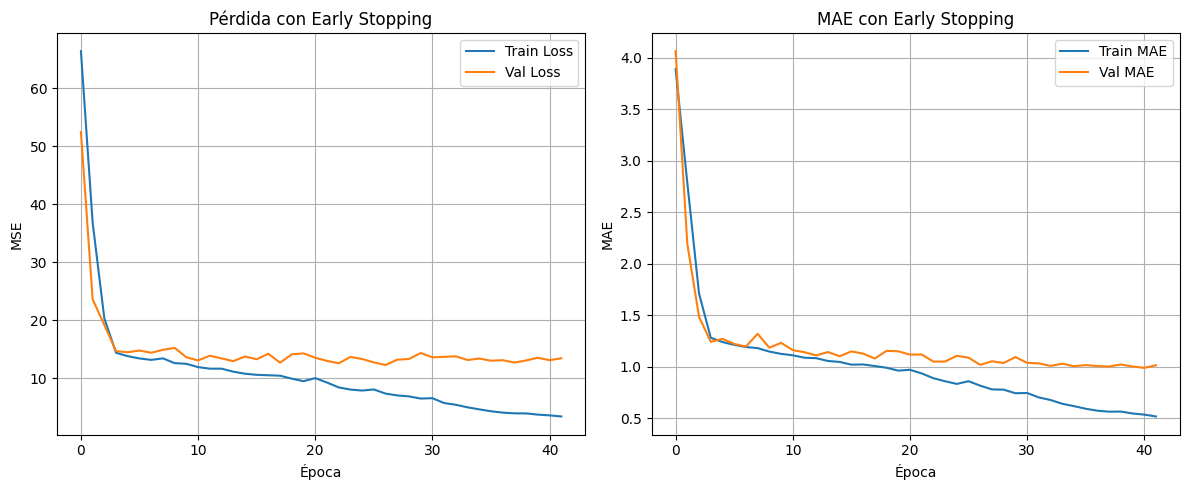

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step


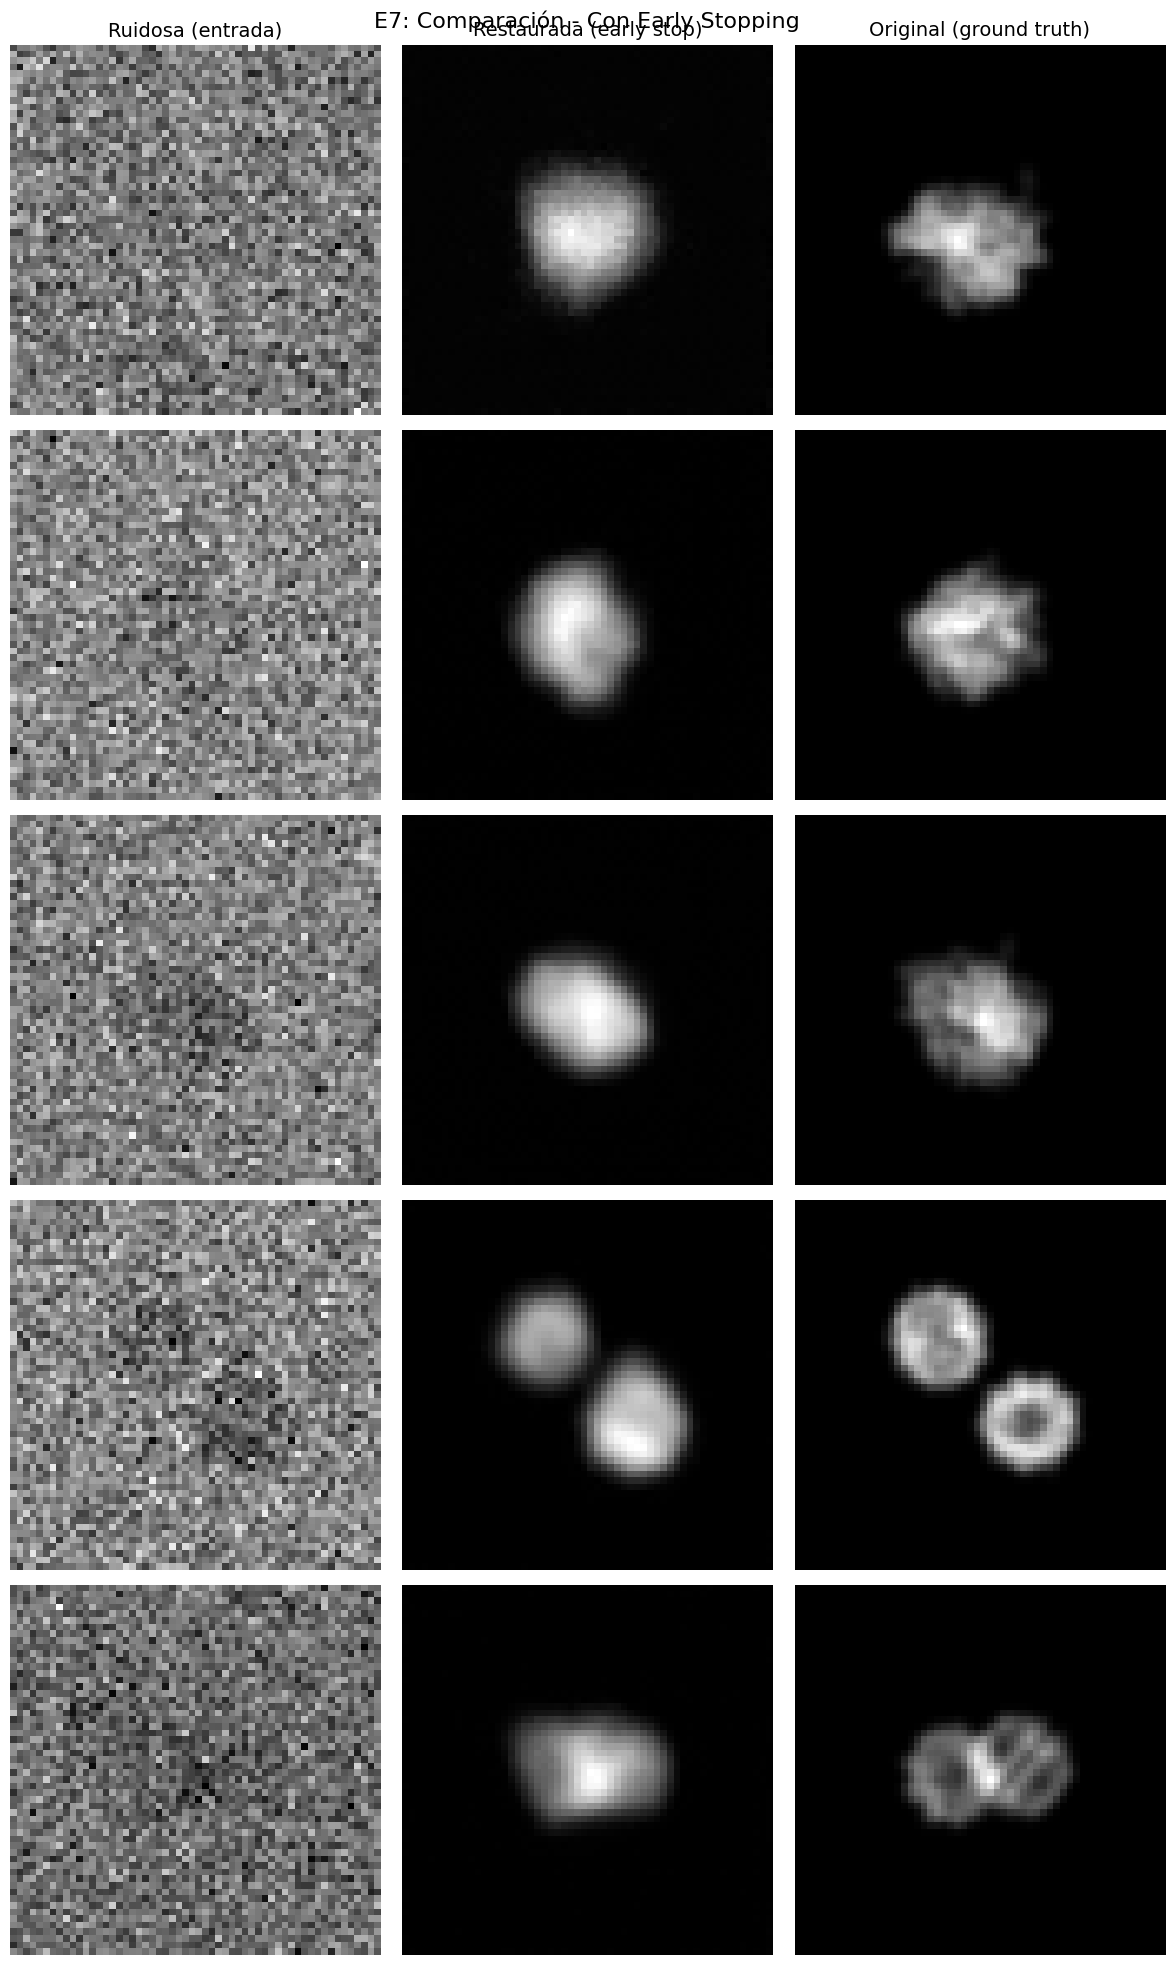


E7 - Análisis:
- Entrenamiento sin Early Stopping: 200 épocas
- Entrenamiento con Early Stopping: 42 épocas
- Val Loss sin ES: 14.228929 | Val MAE sin ES: 1.021912
- Val Loss con ES: 12.247510 | Val MAE con ES: 1.018146

- El entrenamiento con Early Stopping dura menos épocas, ahorrando tiempo.
- El Early Stopping detiene el entrenamiento cuando la val_loss deja de mejorar,
  evitando el sobreajuste.
- Al restaurar los mejores pesos (restore_best_weights=True), el modelo final
  corresponde al punto óptimo antes del sobreajuste, consiguiendo generalmente
  un mejor resultado en validación.
- La restauración debería ser más fiel a la imagen original, con menos
  artefactos introducidos por el sobreajuste.



In [7]:
# ============================================================
# E7: Entrenamiento con Early Stopping
# ============================================================

# Reconstruir el modelo desde cero
model_es = build_unet(input_shape=(TARGET_SIZE, TARGET_SIZE, 1))
model_es.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Configurar Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',      # Monitorizar la pérdida de validación
    patience=15,             # Esperar 15 épocas sin mejora antes de parar
    restore_best_weights=True,  # Restaurar los pesos del mejor modelo
    verbose=1
)

# Entrenamiento con early stopping
history_es = model_es.fit(
    X_train, Y_train,
    validation_data=(X_val, Y_val),
    epochs=200,              # Máximo de épocas (se detendrá antes)
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

n_epochs_es = len(history_es.history['loss'])
print(f"\nEntrenamiento detenido en la época: {n_epochs_es}")

# Visualizar curvas de pérdida con early stopping
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_es.history['loss'], label='Train Loss')
plt.plot(history_es.history['val_loss'], label='Val Loss')
plt.xlabel('Época')
plt.ylabel('MSE')
plt.title('Pérdida con Early Stopping')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_es.history['mae'], label='Train MAE')
plt.plot(history_es.history['val_mae'], label='Val MAE')
plt.xlabel('Época')
plt.ylabel('MAE')
plt.title('MAE con Early Stopping')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('e7_training_curves_es.png', dpi=150)
plt.show()

# Predicciones con el modelo con early stopping
predictions_es = model_es.predict(X_val)

# Mostrar algunos ejemplos
fig, axes = plt.subplots(n_examples, 3, figsize=(12, 4 * n_examples))
axes[0, 0].set_title('Ruidosa (entrada)', fontsize=14)
axes[0, 1].set_title('Restaurada (early stop)', fontsize=14)
axes[0, 2].set_title('Original (ground truth)', fontsize=14)

for i in range(n_examples):
    axes[i, 0].imshow(X_val[i, :, :, 0], cmap='gray')
    axes[i, 0].axis('off')

    axes[i, 1].imshow(predictions_es[i, :, :, 0], cmap='gray')
    axes[i, 1].axis('off')

    axes[i, 2].imshow(Y_val[i, :, :, 0], cmap='gray')
    axes[i, 2].axis('off')

plt.suptitle('E7: Comparación - Con Early Stopping', fontsize=16)
plt.tight_layout()
plt.savefig('e7_comparison_es.png', dpi=150)
plt.show()

# Comparar métricas finales
val_loss_no_es = model.evaluate(X_val, Y_val, verbose=0)
val_loss_es = model_es.evaluate(X_val, Y_val, verbose=0)

print(f"""
E7 - Análisis:
- Entrenamiento sin Early Stopping: 200 épocas
- Entrenamiento con Early Stopping: {n_epochs_es} épocas
- Val Loss sin ES: {val_loss_no_es[0]:.6f} | Val MAE sin ES: {val_loss_no_es[1]:.6f}
- Val Loss con ES: {val_loss_es[0]:.6f} | Val MAE con ES: {val_loss_es[1]:.6f}

- El entrenamiento con Early Stopping dura menos épocas, ahorrando tiempo.
- El Early Stopping detiene el entrenamiento cuando la val_loss deja de mejorar,
  evitando el sobreajuste.
- Al restaurar los mejores pesos (restore_best_weights=True), el modelo final
  corresponde al punto óptimo antes del sobreajuste, consiguiendo generalmente
  un mejor resultado en validación.
- La restauración debería ser más fiel a la imagen original, con menos
  artefactos introducidos por el sobreajuste.
""")